In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import astropy.units as u
from pathlib import Path
from astropy.coordinates import SkyCoord
from astromodels.functions.function import Function1D, FunctionMeta
from cosipy import SpacecraftFile, SourceInjector
from cosipy.response import FullDetectorResponse, ExtendedSourceResponse
from histpy import Histogram
from mhealpy import HealpixMap
from threeML import Powerlaw, Band, Model, PointSource, Gaussian, ExtendedSource, Gaussian_on_sphere
# from astromodels import ExtendedSource, Gaussian_on_sphere
from cosipy.threeml.custom_functions import SpecFromDat, Wide_Asymm_Gaussian_on_sphere
from cosipy.util import fetch_wasabi_file

import shutil
import os
import h5py as h5

In [2]:
DATA_DIR = Path("../../")

In [3]:
ori_path = DATA_DIR / 'DC3/data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori'

# Read the 3-month orientation
# It is the pointing of the spacecraft during the the mock simlulation
ori = SpacecraftFile.parse_from_file(ori_path)

In [4]:
def spectrum_reset(spec, F=None, mu=None, sigma=None):

    spec.F.min_value = F.value / 5
    spec.F.max_value = F.value * 5
    spec.F.value = F.value
    spec.F.unit = F.unit
    spec.mu.min_value = mu.value - 2
    spec.mu.max_value = mu.value + 2
    spec.mu.value = mu.value 
    spec.mu.unit = mu.unit
    spec.sigma.min_value = 0.2
    spec.sigma.max_value = sigma.value + 5
    spec.sigma.value = sigma.value
    spec.sigma.unit = sigma.unit

    spec.F.free = True
    spec.mu.free = True
    spec.sigma.free = True

    return spec

In [5]:
def simulate_point_sources(spec, rsp_path, point_sources, mu=1157.02, sig=3.85):
    # point_sources expected format
    ## list of tuples
    ## tuple[0] = Source Name
    ## tuple[1] = l in deg
    ## tuple[2] = b in deg
    ## tuple[3] = flux only scalar value
    injector = SourceInjector(response_path = rsp_path)

    mu = mu * u.keV
    sigma = sig * u.keV

    for src in point_sources:
        # Define the coordinate of the point source
        source_coord = SkyCoord(l = src[1], b = src[2], frame = "galactic", unit = "deg")

        # define the point source
        F = src[3] / u.cm / u.cm / u.s
        spectrum = spectrum_reset(spec, F=F, mu=mu, sigma=sigma)
        point_source = PointSource(src[0], l = source_coord.l.deg, b = source_coord.b.deg, spectral_shape=spectrum)

        # define the model. The model can contain multiple point sources.
        model = Model(point_source)

        file_path = f"{src[0]}.h5"

        # Check if the file exists and remove it if it does
        if os.path.exists(file_path):
            raise FileExistsError

        # Get the data of the injected source
        model_injected = injector.inject_model(model = model, orientation = ori, make_spectrum_plot = True, data_save_path = file_path)

### 44Ti

16:52:33 WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.0.   ]8;id=154515;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=158886;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

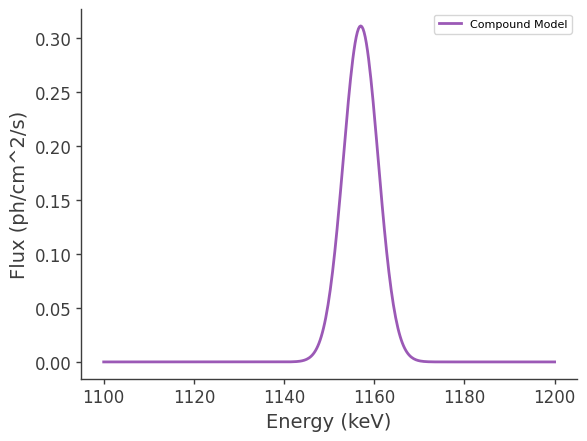

In [8]:
F = 3 / u.cm**2 / u.s
mu = 1157 * u.keV
sigma = 3.85 * u.keV
spectrum = spectrum_reset(Gaussian(), F, mu, sigma)

# Generate some data for plotting
x_data = np.linspace(1100, 1200, 401)
y_data = spectrum(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [9]:
CasAsymmetric = 'CasAsymmetric', 111.734745, -2.129570, 3e-4        # 1000 km/s

SN1987A = 'SN1987A', 279.7, -31.9, 7e-6
Tycho = 'Tycho', 120.1, +1.4, 16e-6
Kepler = 'Kepler', 4.5, +6.8, 10e-6 
VelaJr = 'VelaJr', 266.3, -1.2, 28e-6
G1903 = 'G1903', 1.9, +0.3, 10e-6

STS1 = 'STS1', 80.2, +0.8, 1e-6
STS2 = 'STS2', 81.2, +0.9, 2e-6
STS3 = 'STS3', 84.0, -1.3, 1e-6
STS4 = 'STS4', 283.8, +75.5, 2e-6
STS5 = 'STS5', 184.6, -5.8, 1e-6
STS6 = 'STS6', 266.3, -49.7, 1e-6

known_SNRs = [SN1987A, Tycho, Kepler, VelaJr, G1903]
STS_SNRs = [STS1, STS2, STS3, STS4, STS5, STS6]

In [ ]:
response_path = DATA_DIR / 'DC3/data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'

FileExistsError: 

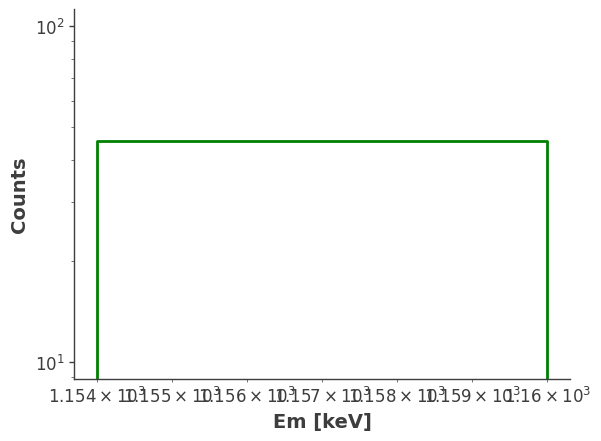

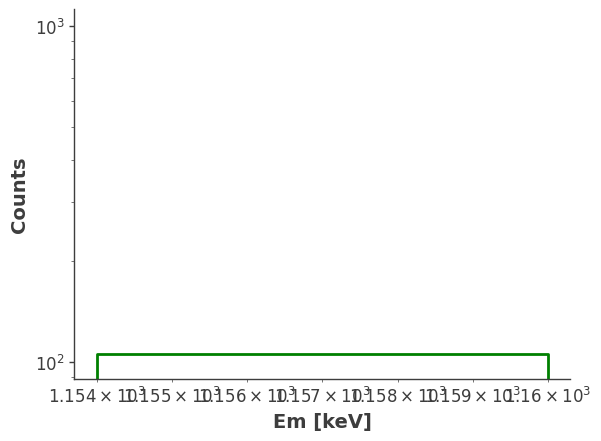

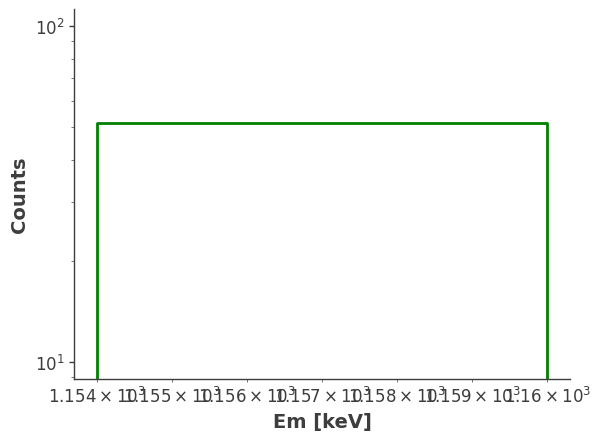

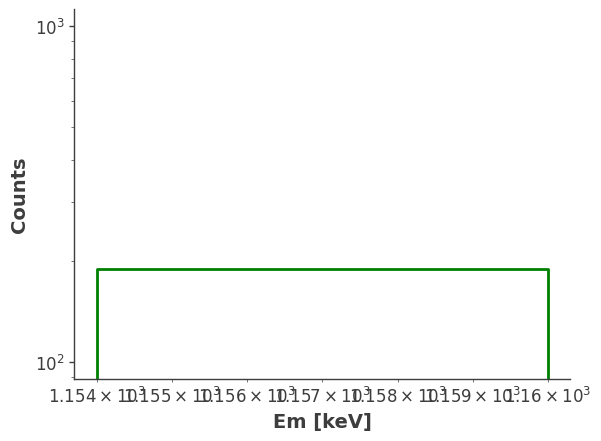

In [ ]:
simulate_point_sources(Gaussian(), response_path, known_SNRs, sig=3.85 * 4)

15:04:59 WARNING   The current value of the parameter F (1e-05) was above the new maximum          ]8;id=521019;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=257993;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  4.9999999999999996e-06.                                                                          

         WARNING   The current value of the parameter sigma (15.4) was above the new maximum 12.7. ]8;id=822483;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=348221;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

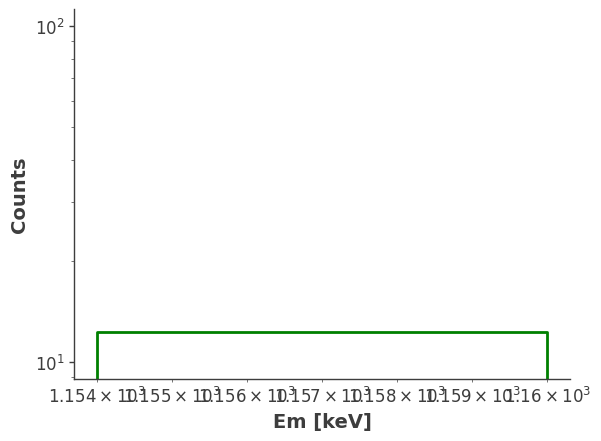

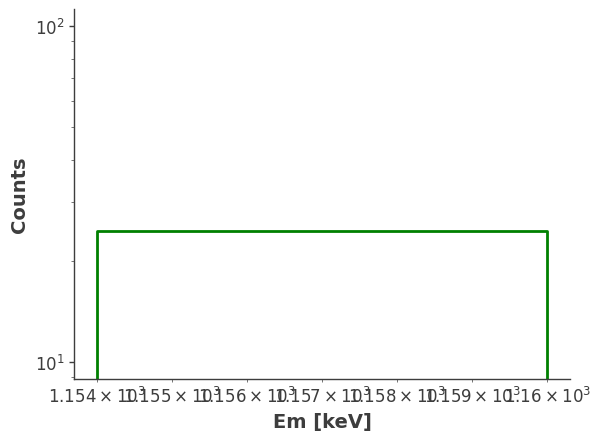

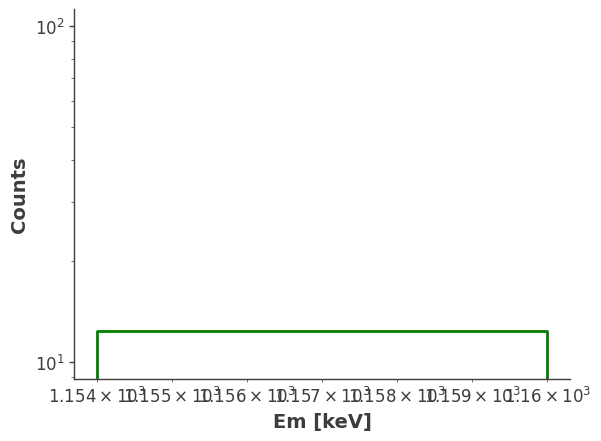

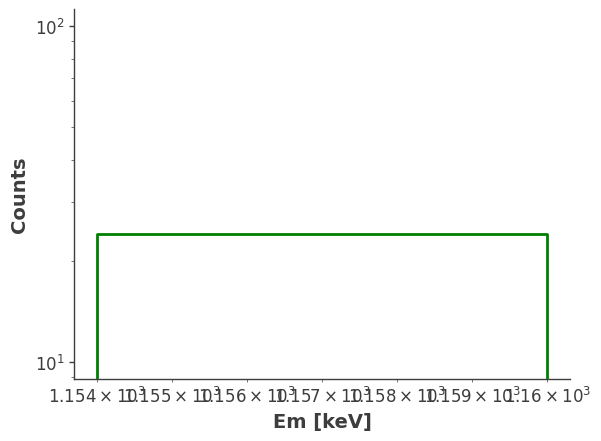

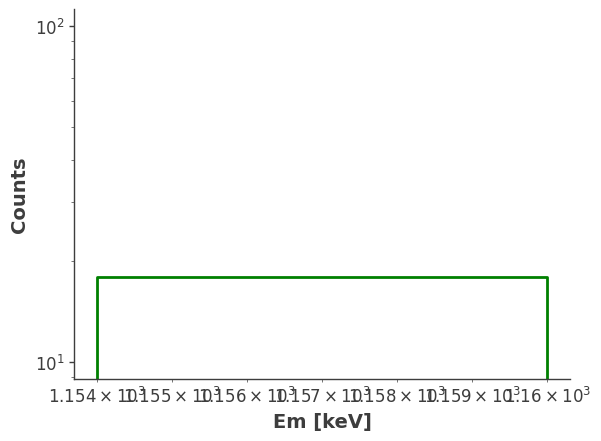

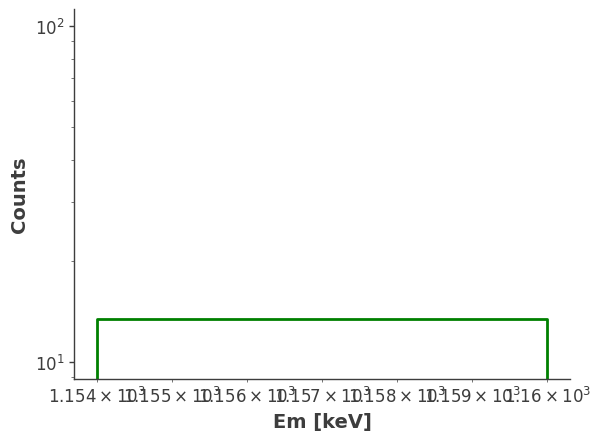

In [23]:
simulate_point_sources(Gaussian(), response_path, STS_SNRs, sig=3.85 * 2)

16:54:34 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=329043;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=348175;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  0.0014999999999999998.                                                                           

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1155.02.  ]8;id=662130;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=749346;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

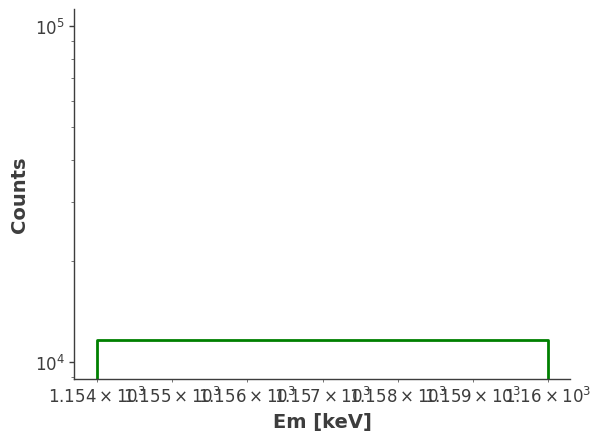

In [12]:
simulate_point_sources(Gaussian(), response_path, [CasAsymmetric], sig=3.85 / 2.355)

#### Sanity Checks

In [ ]:
from cosipy import BinnedData
from histpy import Histogram
import numpy as np
import matplotlib.pyplot as plt

08:19:34 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=133291;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=872868;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=860070;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=966265;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=867848;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=159142;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=310349;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=508958;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

08:19:36 WARNING   No fermitools installed                                              ]8;id=700981;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=857445;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=340518;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=167182;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=286727;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=630575;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=153343;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=660891;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [ ]:
src = BinnedData('../../DC3/44Ti/inputs.yaml')
src.energy_bins = [1154, 1160]  # Takes list. Needs to match response.
src.time_bins = 86400 * 93      # time bin size in seconds. Takes int, float, or list of bin edges.
src.get_binned_data('../../DC3/44Ti/sources/CasAsymmetric_3months_unbinned_data_filtered_with_SAAcut.fits')

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


In [3]:
src.binned_data.axes.labels

array(['Time', 'Em', 'Phi', 'PsiChi'], dtype='<U6')

In [4]:
src_inj = Histogram.open('44Ti/CasAsymmetric.h5')

(10000.0, 15000.0)

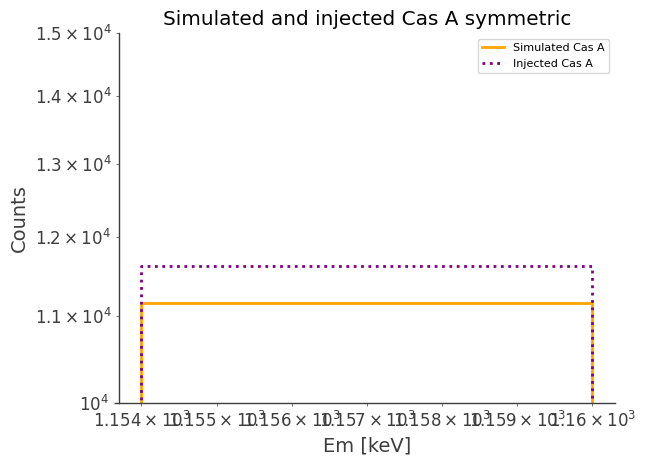

In [5]:
simulated = src.binned_data
injected = src_inj

ax,plot = simulated.project("Em").draw(label = "Simulated Cas A", color = "orange")
injected.project("Em").draw(ax, label = "Injected Cas A", color = "purple", linestyle = "dotted")

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Cas A symmetric")
ax.set_ylim([1e4, 1.5e4])

Text(0.5, 1.0, 'Simulated and injected Cas A symmetric')

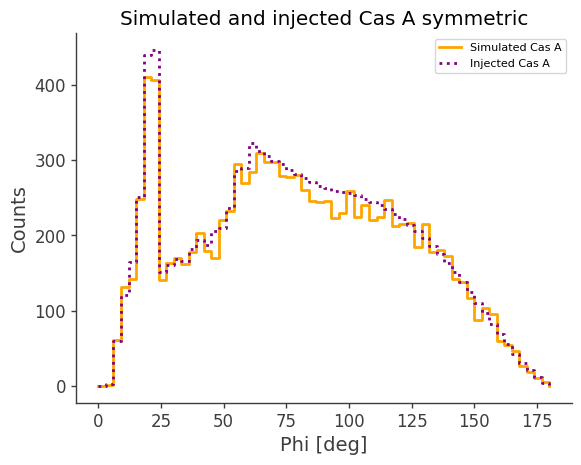

In [ ]:
ax,plot = simulated.project("Phi").draw(label = "Simulated Cas A", color = "orange")
injected.project("Phi").draw(ax, label = "Injected Cas A", color = "purple", linestyle = "dotted")

ax.legend()
ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Cas A symmetric")

Text(0.5, 1.0, 'Simulated and injected Cas A symmetric')

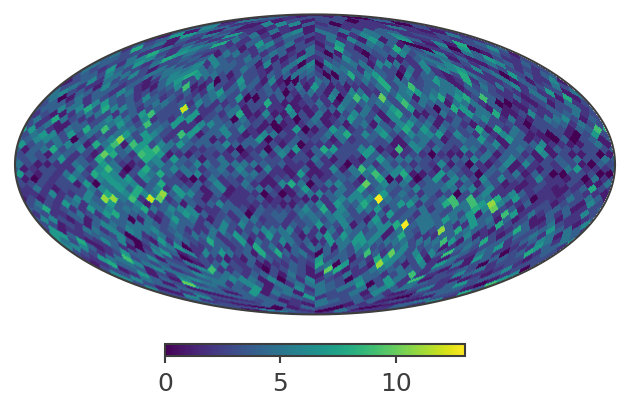

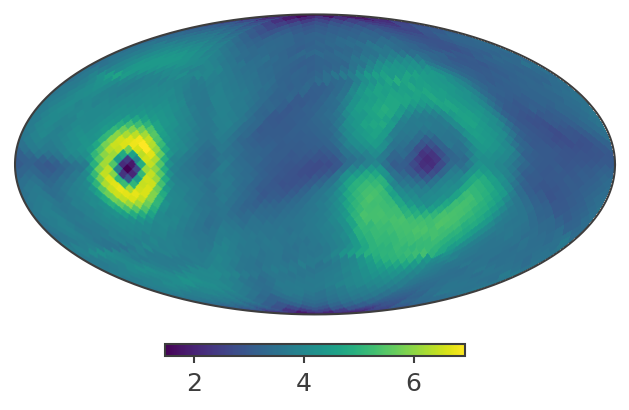

In [15]:
ax1,plot1 = simulated.project("PsiChi").draw(label = "Simulated Cas A")
ax2,plot2 = injected.project("PsiChi").draw(label = "Injected Cas A")

# ax1.legend()
# ax.set_ylabel("Counts")
ax.set_title("Simulated and injected Cas A symmetric")

### 26Al

#### Point Sources

In [6]:
point_sources_26Al = [('VelaJr26Al', 266.3, -1.2, 2e-5), ('gamma2velorum26Al', 262.8, -7.7, 1.1e-6)]
point_sources_60Fe_low = [('VelaJr60Fe_low', 266.3, -1.2, 4e-6)]
point_sources_60Fe_high = [('VelaJr60Fe_high', 266.3, -1.2, 4e-6)]

17:18:12 WARNING   The current value of the parameter F (1.0) was above the new maximum 0.0001.    ]8;id=972752;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=853166;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=198634;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=277826;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

17:33:39 WARNING   The current value of the parameter F (2e-05) was above the new maximum 5.5e-06. ]8;id=898560;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=383808;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

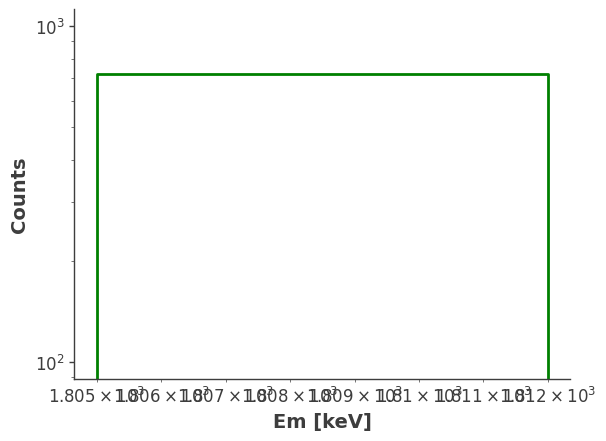

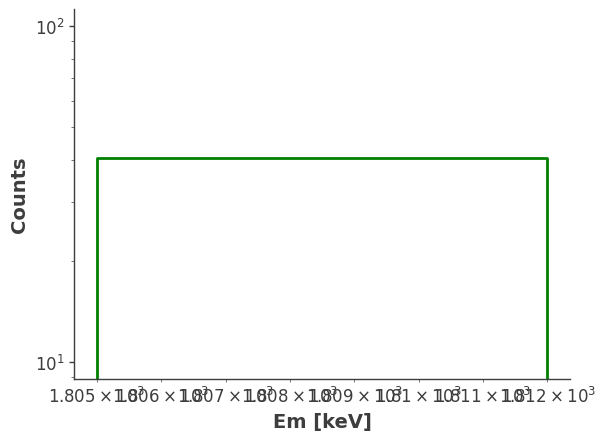

In [9]:
# 26Al
response_path_26Al = DATA_DIR / 'DC3/data/responses/Response26Al.o4.e1805_1812.s10036231691364.m1045.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_26Al, point_sources_26Al, sig=0.77, mu=1808.68)

17:44:02 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=965149;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=479851;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  1.9999999999999998e-05.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1171.23.  ]8;id=293409;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=655594;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

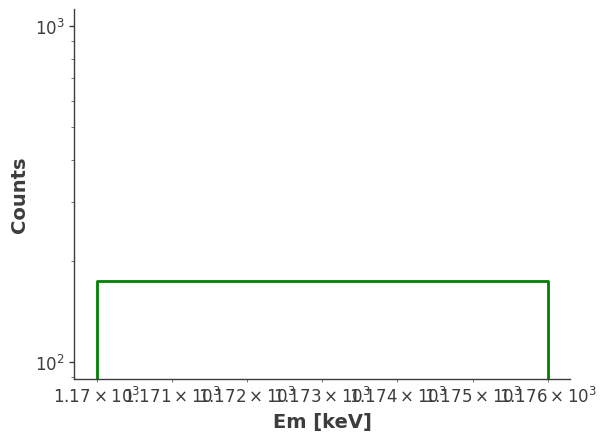

In [10]:
# 60Fe low
response_path_60Fe_low = DATA_DIR / 'DC3/data/responses/Response60FeLow.o4.e1170_1176.s9552269354945.m1188.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_60Fe_low, point_sources_60Fe_low, sig=0.77, mu=1173.23)

17:53:42 WARNING   The current value of the parameter F (1.0) was above the new maximum            ]8;id=881518;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=568880;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\
                  1.9999999999999998e-05.                                                                          

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=338693;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=449888;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

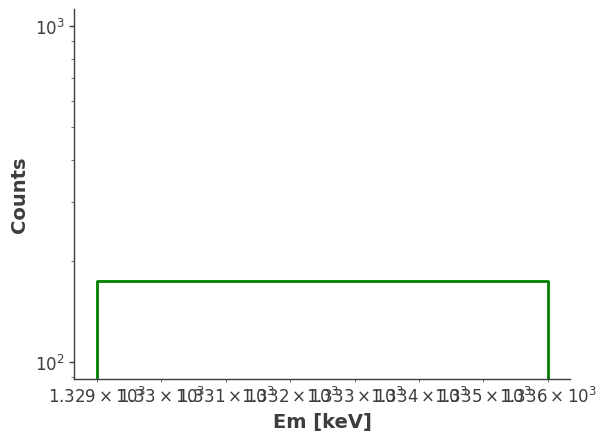

In [11]:
# 60Fe high
response_path_60Fe_high = DATA_DIR / 'DC3/data/responses/Response60FeHigh.o4.e1329_1336.s10201526728102.m1287.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.good_chunks.h5'
simulate_point_sources(Gaussian(), response_path_60Fe_high, point_sources_60Fe_high, sig=0.77, mu=1332.5)

#### Extended Sources

In [6]:
USco_26Al = 'USco_26Al', 348.5, +22.5, 9, 9, 0, 6e-5        # TODO: theta values?
UCL_26Al = 'UCL_26Al', 322.5, +17.0, 15.5, 10.5, 0, 1e-5
LCC_26Al = 'LCC_26Al', 300.5, +6.5, 9, 9, 0, 1e-5
POB2_26Al = 'POB2_26Al', 168.5, -6.5, 6, 6, 0, 5e-5
VelaSNR_26Al = 'VelaSNR_26Al', 263.9, -3.4, 4.25, 4.25, 0, 1.4e-6
Gum_26Al = 'Gum_26Al', 258.0, -2.0, 18, 18, 0, 0.8e-6
OrEr_26Al = 'OrEr_26Al', 163.0, -22.0, 5, 5, 0, 3e-5
LMC_26Al = 'LMC_26Al', 280.5, -32.9, 3.5, 1.5, 0, 2e-6
IVS_26Al = 'IVS_26Al', 263.0, -7.0, 7.5, 7.5, 0, 1.1e-6

USco_60Fe = 'USco_60Fe', 348.5, +22.5, 9, 9, 0, 4.5e-5        # TODO: theta values?
UCL_60Fe = 'UCL_60Fe', 322.5, +17.0, 15.5, 10.5, 0, 1.5e-5
LCC_60Fe = 'LCC_60Fe', 300.5, +6.5, 9, 9, 0, 1.5e-5
POB2_60Fe = 'POB2_60Fe', 168.5, -6.5, 6, 6, 0, 4e-5
VelaSNR_60Fe = 'VelaSNR_60Fe', 263.9, -3.4, 4.25, 4.25, 0, 0.3e-6
Gum_60Fe = 'Gum_60Fe', 258.0, -2.0, 18, 18, 0, 0.2e-6
OrEr_60Fe = 'OrEr_60Fe', 163.0, -22.0, 5, 5, 0, 3e-5
LMC_60Fe = 'LMC_60Fe', 280.5, -32.9, 3.5, 1.5, 0, 0.5e-6
IVS_60Fe = 'IVS_60Fe', 263.0, -7.0, 7.5, 7.5, 0, 0.8e-6

In [68]:
# 26Al
src = IVS_26Al
response_path_26Al = DATA_DIR / 'DC3/data/responses/extended_source_response_Al26_merged.h5'
injector = SourceInjector(response_path = response_path_26Al, response_frame = "galactic")

In [ ]:
# Define spectrum:
# Note that the units of the Gaussian function below are [F/sigma]=[ph/cm2/s/keV]
F = src[6] / u.cm / u.cm / u.s
mu = 1808.68 * u.keV
sigma = 0.77 * u.keV
spectrum = spectrum_reset(Gaussian(), F, mu, sigma)

# Define morphology:
e = np.sqrt(1 - (src[4]/src[3])**2)
morphology = Wide_Asymm_Gaussian_on_sphere(lon0=src[1], lat0=src[2], a=src[3], e=e, theta=src[5])

# Define source:
wide_gaussian_extended_source = ExtendedSource(src[0], spectral_shape=spectrum, spatial_shape=morphology)

model = Model(wide_gaussian_extended_source)

09:32:47 WARNING   The current value of the parameter F (1.0) was above the new maximum 5.5e-06.   ]8;id=543188;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=266916;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=124706;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=737456;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

In [79]:
# 60Fe
src = IVS_60Fe
response_path_60Fe_low = DATA_DIR / 'DC3/data/responses/extended_source_response_Fe60_low_merged.h5'
injector = SourceInjector(response_path = response_path_60Fe_low, response_frame = "galactic")

In [ ]:
# Define spectrum:
# Note that the units of the Gaussian function below are [F/sigma]=[ph/cm2/s/keV]
F = src[6] / u.cm / u.cm / u.s
mu = 1332.5 * u.keV
sigma = 0.77 * u.keV
spectrum = spectrum_reset(Gaussian(), F, mu, sigma)

# Define morphology:
e = np.sqrt(1 - (src[4]/src[3])**2)
morphology = Wide_Asymm_Gaussian_on_sphere(lon0=src[1], lat0=src[2], a=src[3], e=e, theta=src[5])

# Define source:
wide_gaussian_extended_source = ExtendedSource(src[0]+'_low', spectral_shape=spectrum, spatial_shape=morphology)

model = Model(wide_gaussian_extended_source)

10:41:21 WARNING   The current value of the parameter F (1.0) was above the new maximum 4e-06.     ]8;id=556206;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=367665;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1330.5.   ]8;id=332377;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=438631;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

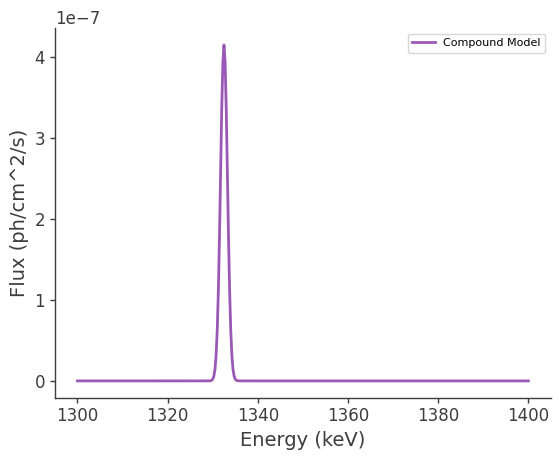

In [96]:
# Generate some data for plotting
x_data = np.linspace(1100, 1200, 401)
x_data = np.linspace(1300, 1400, 401)
# x_data = np.linspace(1750, 1850, 401)
y_data = spectrum(x_data)

# Plot the compound model
plt.plot(x_data, y_data, label="Compound Model")
plt.xlabel("Energy (keV)")
plt.ylabel("Flux (ph/cm^2/s)")
plt.legend()
plt.show()

In [ ]:
# Define healpix map matching the detector response:
skymap = HealpixMap(nside = 16, scheme = "ring", dtype = float, coordsys='galactic')
coords1 = skymap.pix2skycoord(range(skymap.npix))
pix_area = skymap.pixarea().value

# Fill skymap with values from extended source: 
skymap[:] = wide_gaussian_extended_source.Wide_Asymm_Gaussian_on_sphere(coords1.l.deg, coords1.b.deg) 

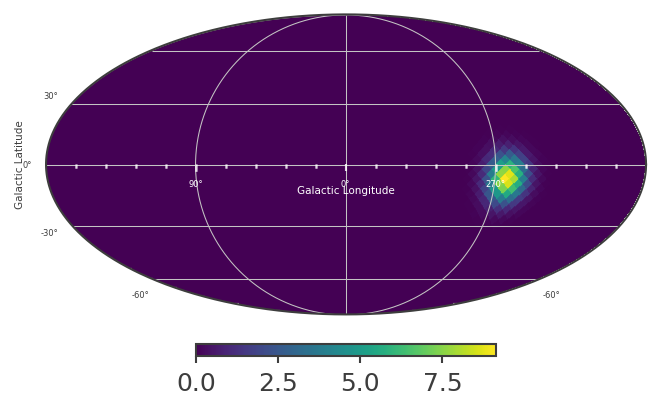

In [74]:
# Plot healpix map:
plot, ax = skymap.plot(ax_kw = {'coord':'G'})
ax.grid()
lon = ax.coords['glon']
lat = ax.coords['glat']
lon.set_axislabel('Galactic Longitude',color='white',fontsize=5)
lat.set_axislabel('Galactic Latitude',fontsize=5)
lon.display_minor_ticks(True)
lat.display_minor_ticks(True)
lon.set_ticks_visible(True)
lon.set_ticklabel_visible(True)
lon.set_ticks(color='white',alpha=0.6)
lat.set_ticks(color='white',alpha=0.6)
lon.set_ticklabel(color='white',fontsize=4)
lat.set_ticklabel(fontsize=4)
lat.set_ticks_visible(True)
lat.set_ticklabel_visible(True)

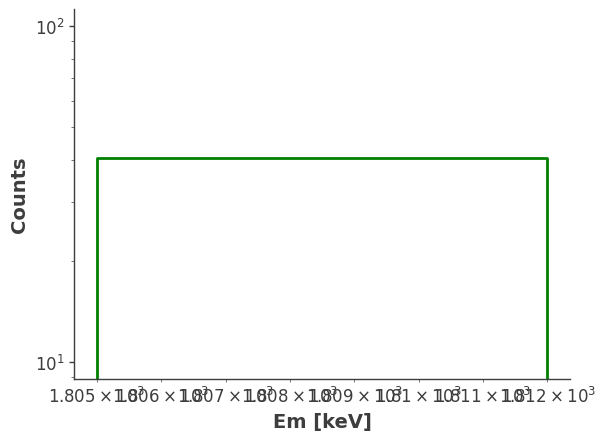

In [75]:
file_path = f"{src[0]}.h5"

# Check if the file exists and remove it if it does
if os.path.exists(file_path):
    os.remove(file_path)
    # raise FileExistsError

# Inject the extended source
model_injected = injector.inject_model(model = model, make_spectrum_plot = True, data_save_path = file_path)

(<Mollview: >, <matplotlib.image.AxesImage at 0x44fe6e620>)

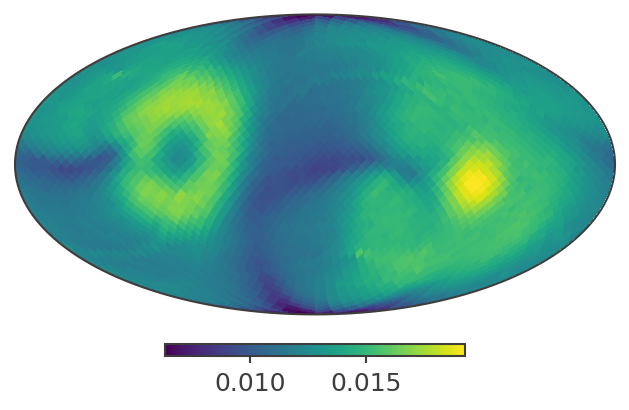

In [77]:
model_injected.project('PsiChi').plot()

(<Axes: xlabel='Phi [deg]'>, <ErrorbarContainer object of 3 artists>)

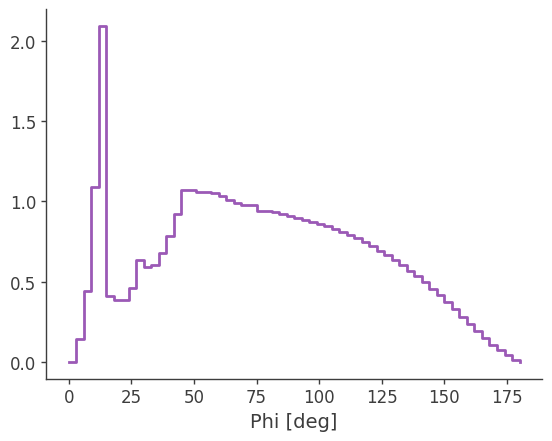

In [78]:
model_injected.project('Phi').plot()

In [106]:
def simulate_extended_sources(spec, rsp_path, extended_sources, sig=0.77, mu=1808.68):
    # point_sources expected format
    ## list of tuples
    ## tuple[0] = Source Name
    ## tuple[1] = l in deg
    ## tuple[2] = b in deg
    ## tuple[3] = a0 in deg
    ## tuple[4] = b0 in deg
    ## tuple[5] = theta in deg
    ## tuple[6] = flux only scalar value
    injector = SourceInjector(response_path = rsp_path, response_frame='galactic')

    mu = mu * u.keV
    sigma = sig * u.keV

    for src in extended_sources:
        src_name = src[0] #+ '_high'

        # define the point source
        F = src[6] / u.cm / u.cm / u.s
        spectrum = spectrum_reset(spec, F=F, mu=mu, sigma=sigma)

        # Define morphology:
        e = np.sqrt(1 - (src[4]/src[3])**2)
        morphology = Wide_Asymm_Gaussian_on_sphere(lon0=src[1], lat0=src[2], a=src[3], e=e, theta=src[5])
        
        wide_gaussian_extended_source = ExtendedSource(src_name, spectral_shape=spectrum, spatial_shape=morphology)
        model = Model(wide_gaussian_extended_source)

        # Define healpix map matching the detector response:
        skymap = HealpixMap(nside = 16, scheme = "ring", dtype = float, coordsys='galactic')
        coords1 = skymap.pix2skycoord(range(skymap.npix))

        # Fill skymap with values from extended source: 
        skymap[:] = wide_gaussian_extended_source.Wide_Asymm_Gaussian_on_sphere(coords1.l.deg, coords1.b.deg) 

        file_path = f"{src_name}.h5"

        # Check if the file exists and remove it if it does
        if os.path.exists(file_path):
            pass
            # raise FileExistsError

        # Inject the extended source
        model_injected = injector.inject_model(model = model, make_spectrum_plot = True, data_save_path = file_path)

In [ ]:
response_path_26Al = DATA_DIR / 'DC3/data/responses/extended_source_response_Al26_merged.h5'
simulate_extended_sources(Gaussian(), response_path_26Al, [USco_26Al], mu=1808.68)

13:51:59 WARNING   The current value of the parameter F (1.0) was above the new maximum 5.5e-06.   ]8;id=314520;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=55494;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu (0.0) was below the new minimum 1806.68.  ]8;id=538477;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=430352;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

ValueError: Unable to write histogram. Another group with the same name already exists. Choose a different name or use overwrite